In [ ]:
#https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [ ]:
data.shape

(7043, 21)

In [ ]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

In [ ]:
data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
data['TotalCharges'] = data['TotalCharges'].fillna(0)

/tmp/ipykernel_14598/2154109872.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Churn', palette='viridis')


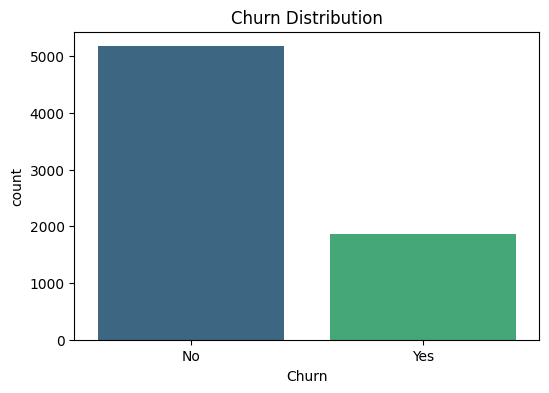

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=data, x='Churn', palette='viridis')
plt.title('Churn Distribution')
plt.show()

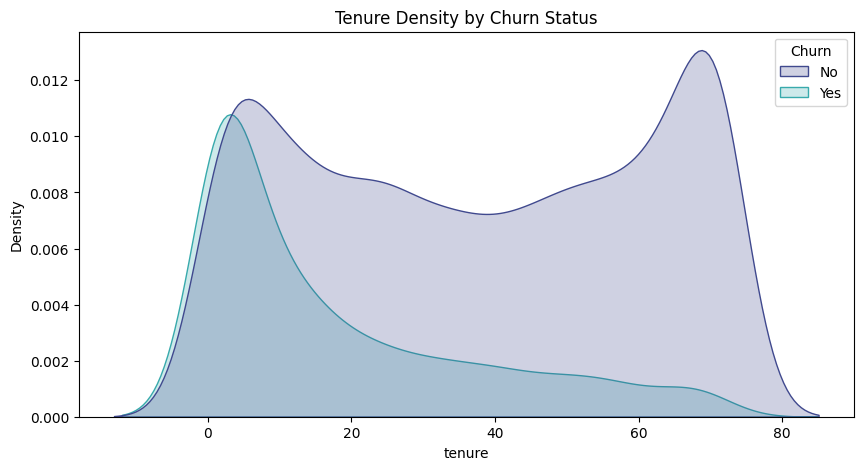

In [ ]:
plt.figure(figsize=(10,5))
sns.kdeplot(data=data, x='tenure', hue='Churn', fill=True, palette='mako')
plt.title('Tenure Density by Churn Status')
plt.show()

In [ ]:
def tenure_group(t):
    if t <= 12: return '0-12 msc'
    elif t <= 24: return '12-24 msc'
    elif t <= 48: return '24-48 msc'
    else: return '> 48 msc'

data['tenure_group'] = data['tenure'].apply(tenure_group)

In [ ]:
services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
data['total_services'] = (data[services] == 'Yes').sum(axis=1)

In [ ]:
corr_data = data.copy()
corr_data['Churn'] = corr_data['Churn'].map({'Yes': 1, 'No': 0})

In [ ]:
corr_data['PaperlessBilling'] = corr_data['PaperlessBilling'].map({'Yes': 1, 'No': 0})

In [ ]:
numeric_data = corr_data.select_dtypes(include=[np.number])

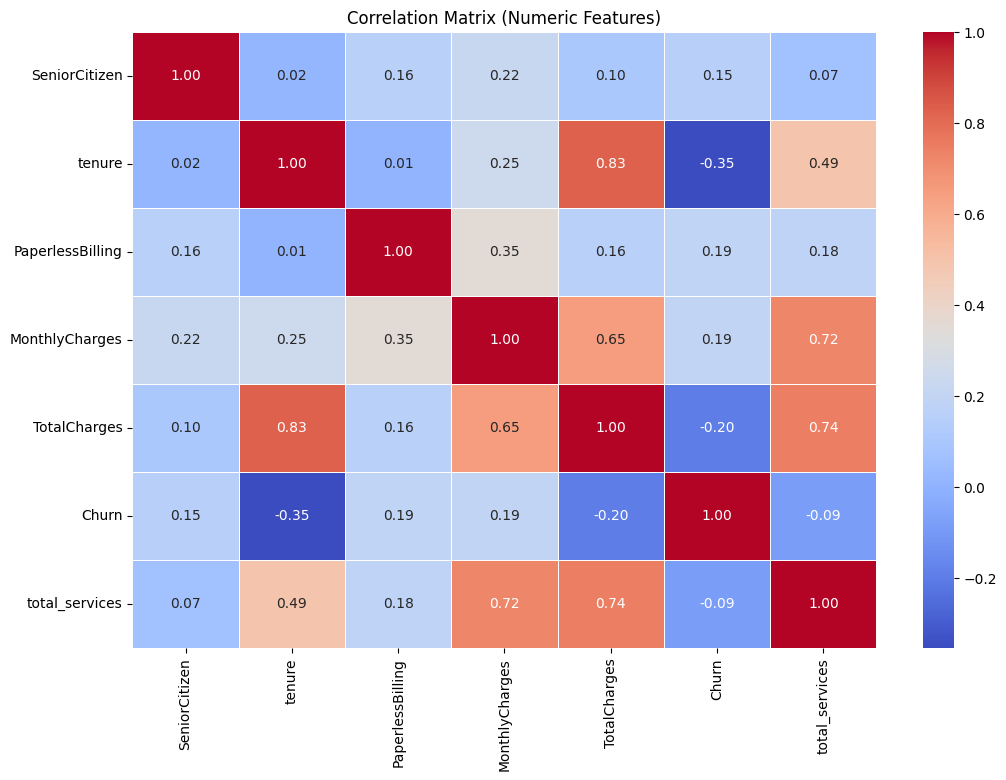

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix (Numeric Features)')
plt.show()

In [ ]:
print(data[['tenure', 'tenure_group', 'total_services']].head())

   tenure tenure_group  total_services
0       1     0-12 msc               1
1      34    24-48 msc               2
2       2     0-12 msc               2
3      45    24-48 msc               3
4       2     0-12 msc               0


In [46]:
data.to_csv("Telco_Churn_Cleaned.csv", index=False)